# Predicting Heart Disease

**Author:** Mike Johnson

**Date Created:** 2026-06-23

**Last Updated:** 2026-06-23

**Objective:** One-sentence description of what this notebook does and why.

**Data Sources:** https://kaggle.com/competitions/playground-series-s6e6

**Key Findings:** (Fill in after analysis is complete.)

**Citation:**<br>
Yao Yan, Walter Reade, Elizabeth Park. Predicting Stellar Class. https://kaggle.com/competitions/playground-series-s6e6, 2026. Kaggle.
****

## 1.0 Setup

In [1]:
# Import standard libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Import ML libraries
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import cross_validate, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, balanced_accuracy_score
from scipy.stats import randint, uniform

# Import models
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

In [2]:
# Set seed
RANDOM_STATE = 206

## 2.0 Data Loading

In [3]:
# Load data
train = pd.read_csv('data/train.csv', index_col='id')
test = pd.read_csv('data/test.csv', index_col='id')

### 2.1 Training Set

In [4]:
# Preview training set
print(f"Training Shape: {train.shape}")
train.head()

Training Shape: (577347, 11)


,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
id,,,,,,,,,,,
0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY
1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY
2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO
3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,GALAXY
4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,GALAXY


In [5]:
# Get info
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 577347 entries, 0 to 577346
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   alpha              577347 non-null  float64
 1   delta              577347 non-null  float64
 2   u                  577347 non-null  float64
 3   g                  577347 non-null  float64
 4   r                  577347 non-null  float64
 5   i                  577347 non-null  float64
 6   z                  577347 non-null  float64
 7   redshift           577347 non-null  float64
 8   spectral_type      577347 non-null  str    
 9   galaxy_population  577347 non-null  str    
 10  class              577347 non-null  str    
dtypes: float64(8), str(3)
memory usage: 48.5 MB


In [6]:
# Describe training set
train.describe(include="all").round(2).T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
alpha,577347.0,NaN,NaN,NaN,181.62,96.24,0.01,132.16,188.68,231.83,360.0
delta,577347.0,NaN,NaN,NaN,21.83,18.93,-17.97,2.47,21.48,36.99,79.16
u,577347.0,NaN,NaN,NaN,22.44,2.02,-0.14,20.98,22.57,23.87,28.25
g,577347.0,NaN,NaN,NaN,21.01,1.8,13.54,19.87,21.47,22.29,27.62
r,577347.0,NaN,NaN,NaN,19.96,1.65,12.58,18.82,20.43,21.16,25.25
i,577347.0,NaN,NaN,NaN,19.38,1.58,11.96,18.31,19.63,20.61,27.91
z,577347.0,NaN,NaN,NaN,19.04,1.58,11.68,17.97,19.19,20.16,26.83
redshift,577347.0,NaN,NaN,NaN,0.72,0.81,-0.01,0.18,0.5,0.88,7.01
spectral_type,577347,4,M,303323,NaN,NaN,NaN,NaN,NaN,NaN,NaN
galaxy_population,577347,2,Red_Sequence,319565,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
print(f"Exact duplicate rows: {train.duplicated().sum()}")
print(f"All-null columns: {train.columns[train.isnull().all()].tolist()}")
print(f"Constant columns: {train.columns[train.nunique() <= 1].tolist()}")

Exact duplicate rows: 0
All-null columns: []
Constant columns: []


### 2.2 Test Set

In [8]:
# Preview test set
print(f"Test Shape: {test.shape}")
test.head()

Test Shape: (247435, 10)


,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population
id,,,,,,,,,,
577347,120.719779,23.924249,23.668066,21.951680,21.086183,20.180032,19.202124,0.429042,G/K,Red_Sequence
577348,219.414419,42.171651,24.902933,22.338822,20.732163,19.860330,19.687691,0.867305,M,Red_Sequence
577349,173.568731,-1.756400,19.427591,18.474633,17.551314,16.570674,16.176765,0.224234,G/K,Blue_Cloud
577350,184.903993,-1.411074,23.121029,21.526855,20.670159,20.417633,20.699095,0.066507,G/K,Red_Sequence
577351,222.487816,15.381403,25.094282,22.643981,21.123173,19.439500,19.094158,0.977218,M,Red_Sequence


In [9]:
# Get info
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 247435 entries, 577347 to 824781
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   alpha              247435 non-null  float64
 1   delta              247435 non-null  float64
 2   u                  247435 non-null  float64
 3   g                  247435 non-null  float64
 4   r                  247435 non-null  float64
 5   i                  247435 non-null  float64
 6   z                  247435 non-null  float64
 7   redshift           247435 non-null  float64
 8   spectral_type      247435 non-null  str    
 9   galaxy_population  247435 non-null  str    
dtypes: float64(8), str(2)
memory usage: 18.9 MB


In [10]:
# Describe test set
test.describe(include="all").round(2).T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
alpha,247435.0,NaN,NaN,NaN,181.36,96.21,0.01,132.02,188.56,231.69,360.0
delta,247435.0,NaN,NaN,NaN,21.85,18.93,-17.96,2.53,21.45,37.06,79.17
u,247435.0,NaN,NaN,NaN,22.44,2.02,13.9,20.98,22.57,23.87,27.84
g,247435.0,NaN,NaN,NaN,21.01,1.8,13.37,19.87,21.47,22.29,27.17
r,247435.0,NaN,NaN,NaN,19.97,1.65,10.39,18.83,20.43,21.17,25.29
i,247435.0,NaN,NaN,NaN,19.38,1.58,10.03,18.31,19.63,20.62,24.57
z,247435.0,NaN,NaN,NaN,19.04,1.59,10.63,17.98,19.2,20.17,25.7
redshift,247435.0,NaN,NaN,NaN,0.72,0.81,-0.01,0.18,0.5,0.88,7.01
spectral_type,247435,4,M,129852,NaN,NaN,NaN,NaN,NaN,NaN,NaN
galaxy_population,247435,2,Red_Sequence,136588,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
print(f"Exact duplicate rows: {test.duplicated().sum()}")
print(f"All-null columns: {test.columns[test.isnull().all()].tolist()}")
print(f"Constant columns: {test.columns[test.nunique() <= 1].tolist()}")

Exact duplicate rows: 0
All-null columns: []
Constant columns: []


## 3.0 Train-Test Split

Train and test sets provided for this competition. 

In [12]:
# Define independent variables
X_train = train.drop(columns = 'class')
X_test = test

# Define target
y_train = train['class']

## 4.0 Exploratory Data Analysis

### 4.1 Target Variable Analysis

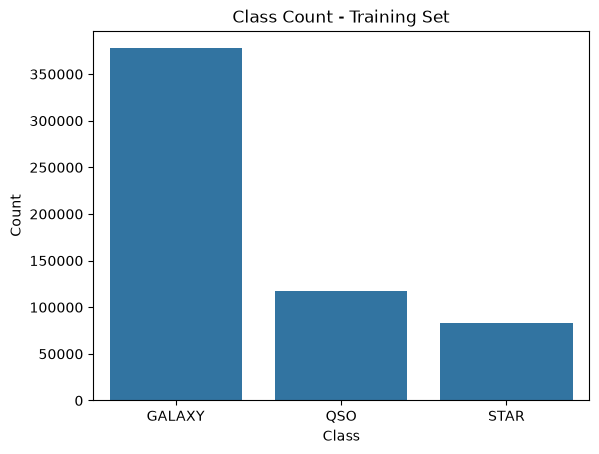

In [13]:
# Visualize counts of each class
sns.countplot(train, x = 'class',)
plt.title('Class Count - Training Set')
plt.xlabel('Class')
plt.ylabel('Count')


plt.show()

### 4.2 Numerical Features

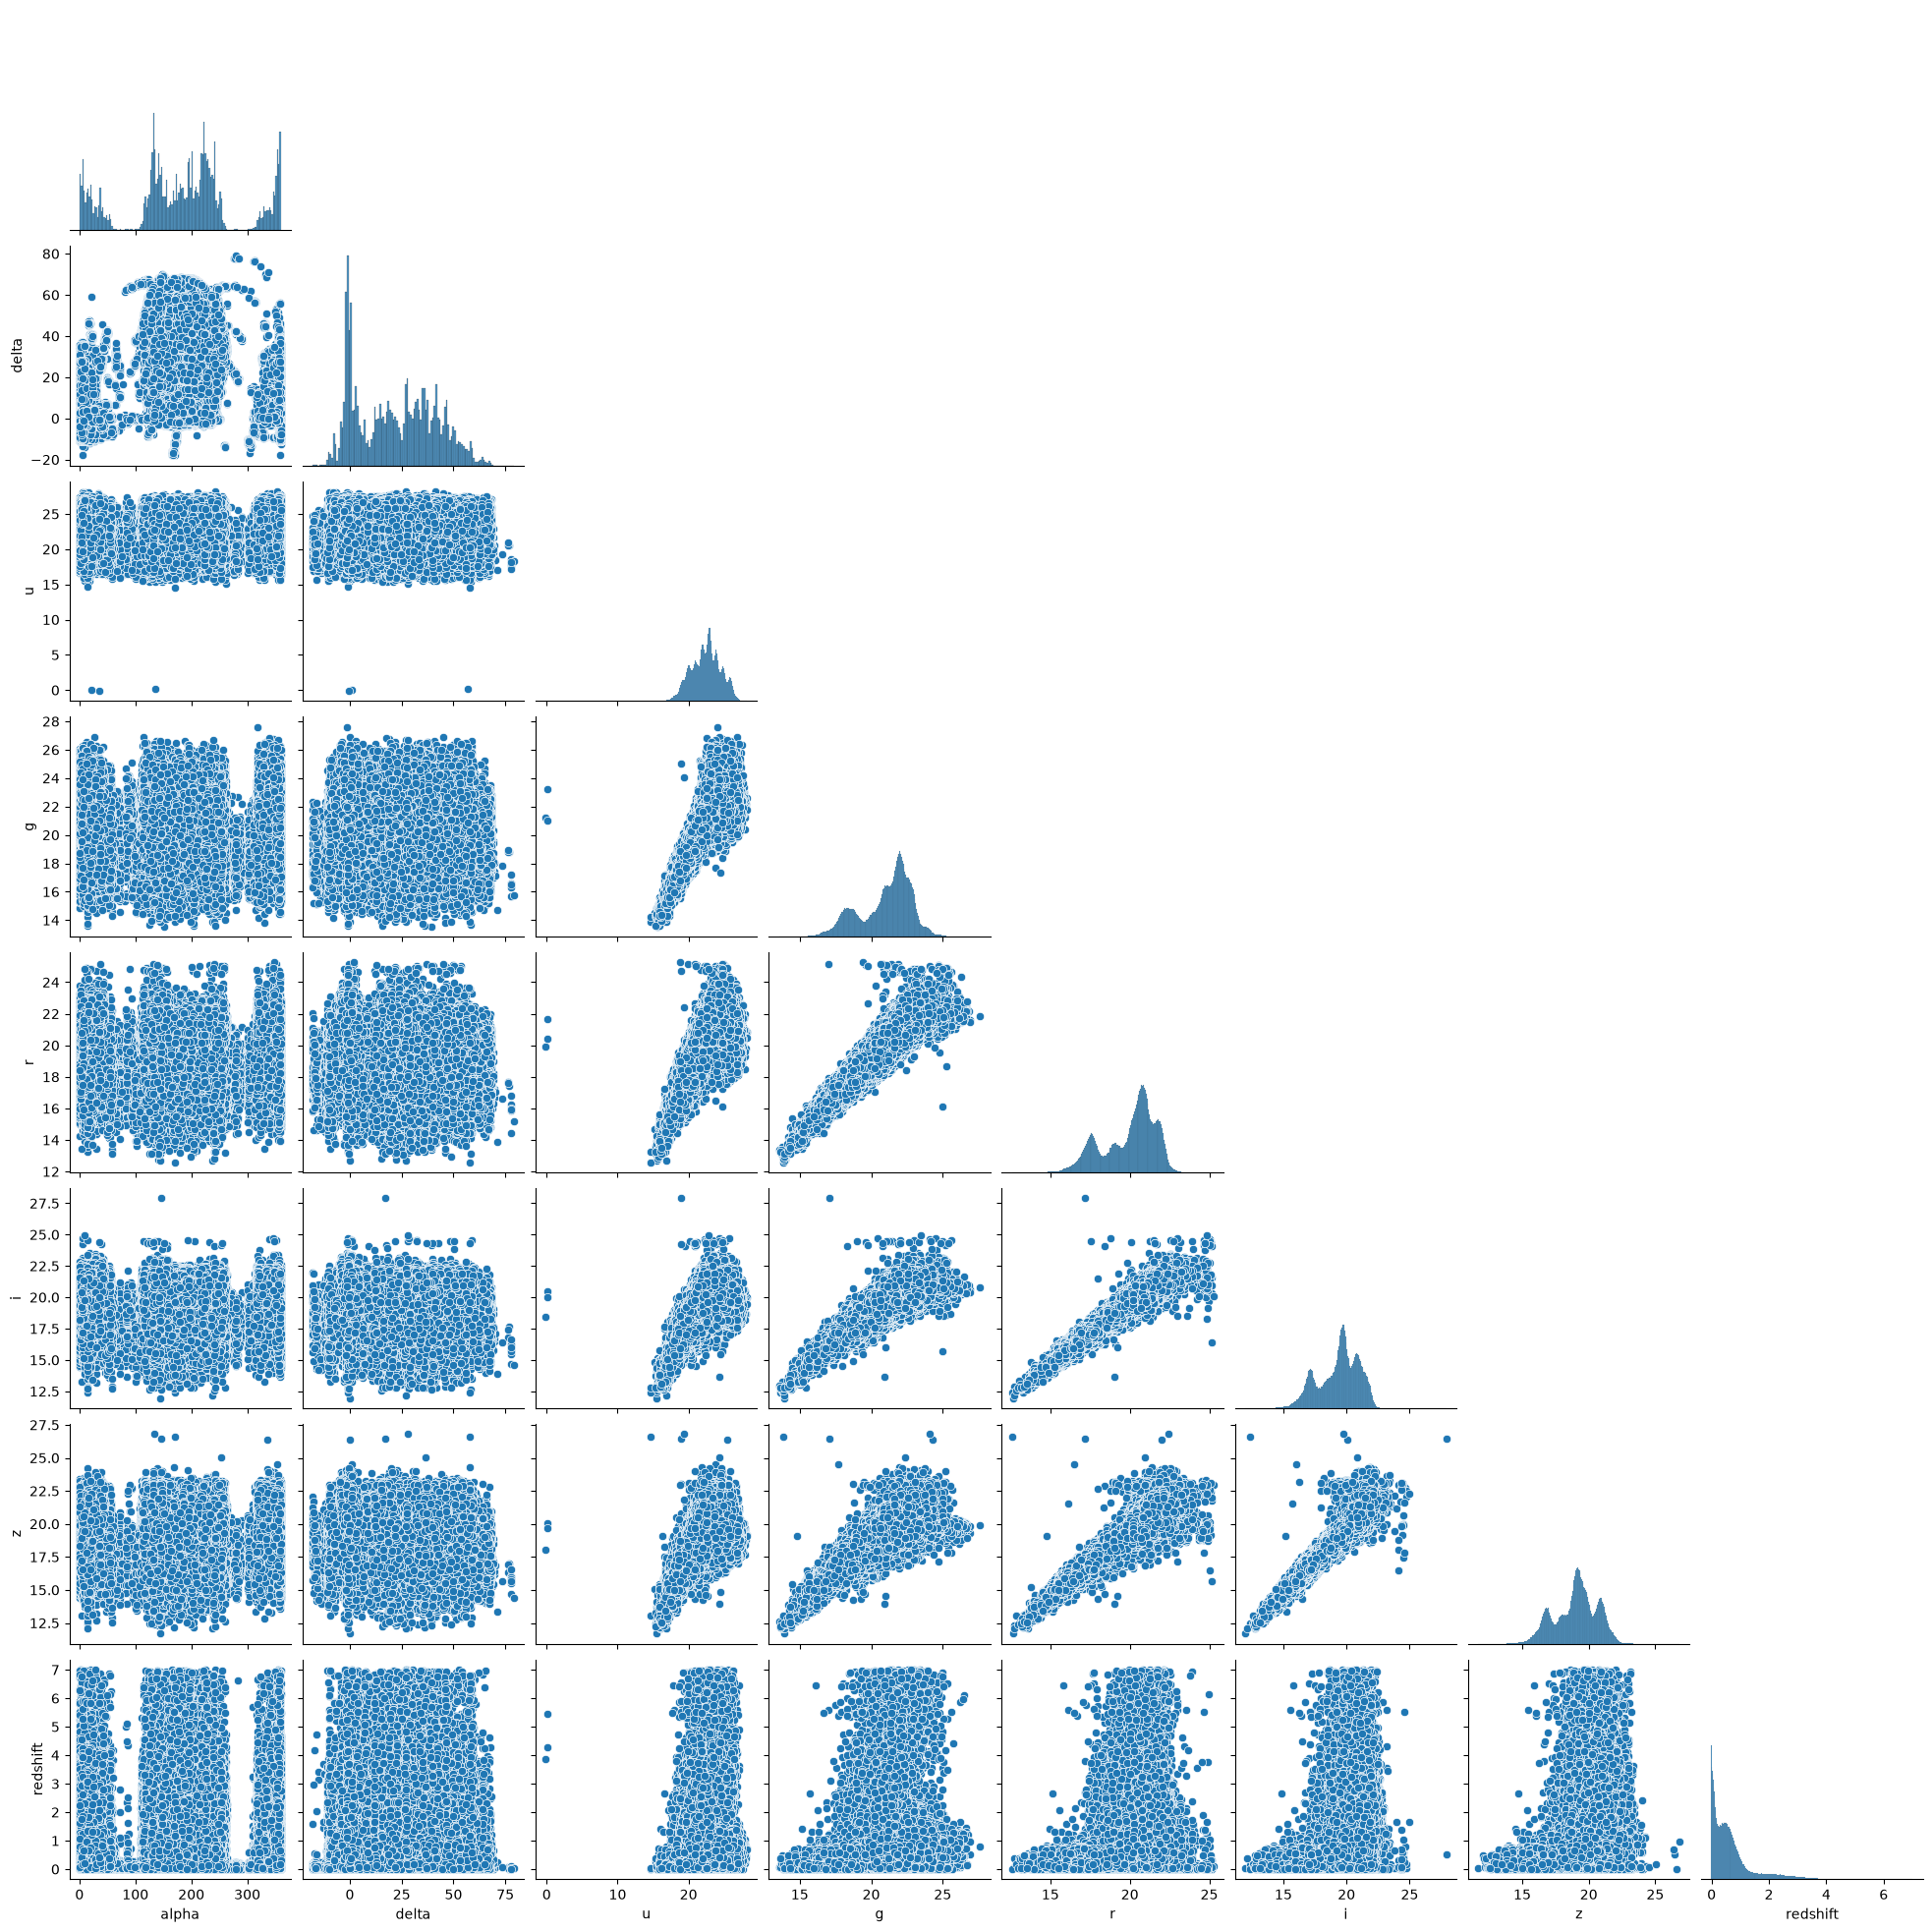

In [14]:
# Visualize using pairplot
sns.pairplot(data = train, corner = True)
plt.show()

Most distributions are multimodal aside from:
- `u` - Normal distribution
- `redshift` - Right-skewed distribution

In addition, `u`, `g`, `r`, `i`, `z` appear to be tightly correlated with each other. But also seeing outliers.

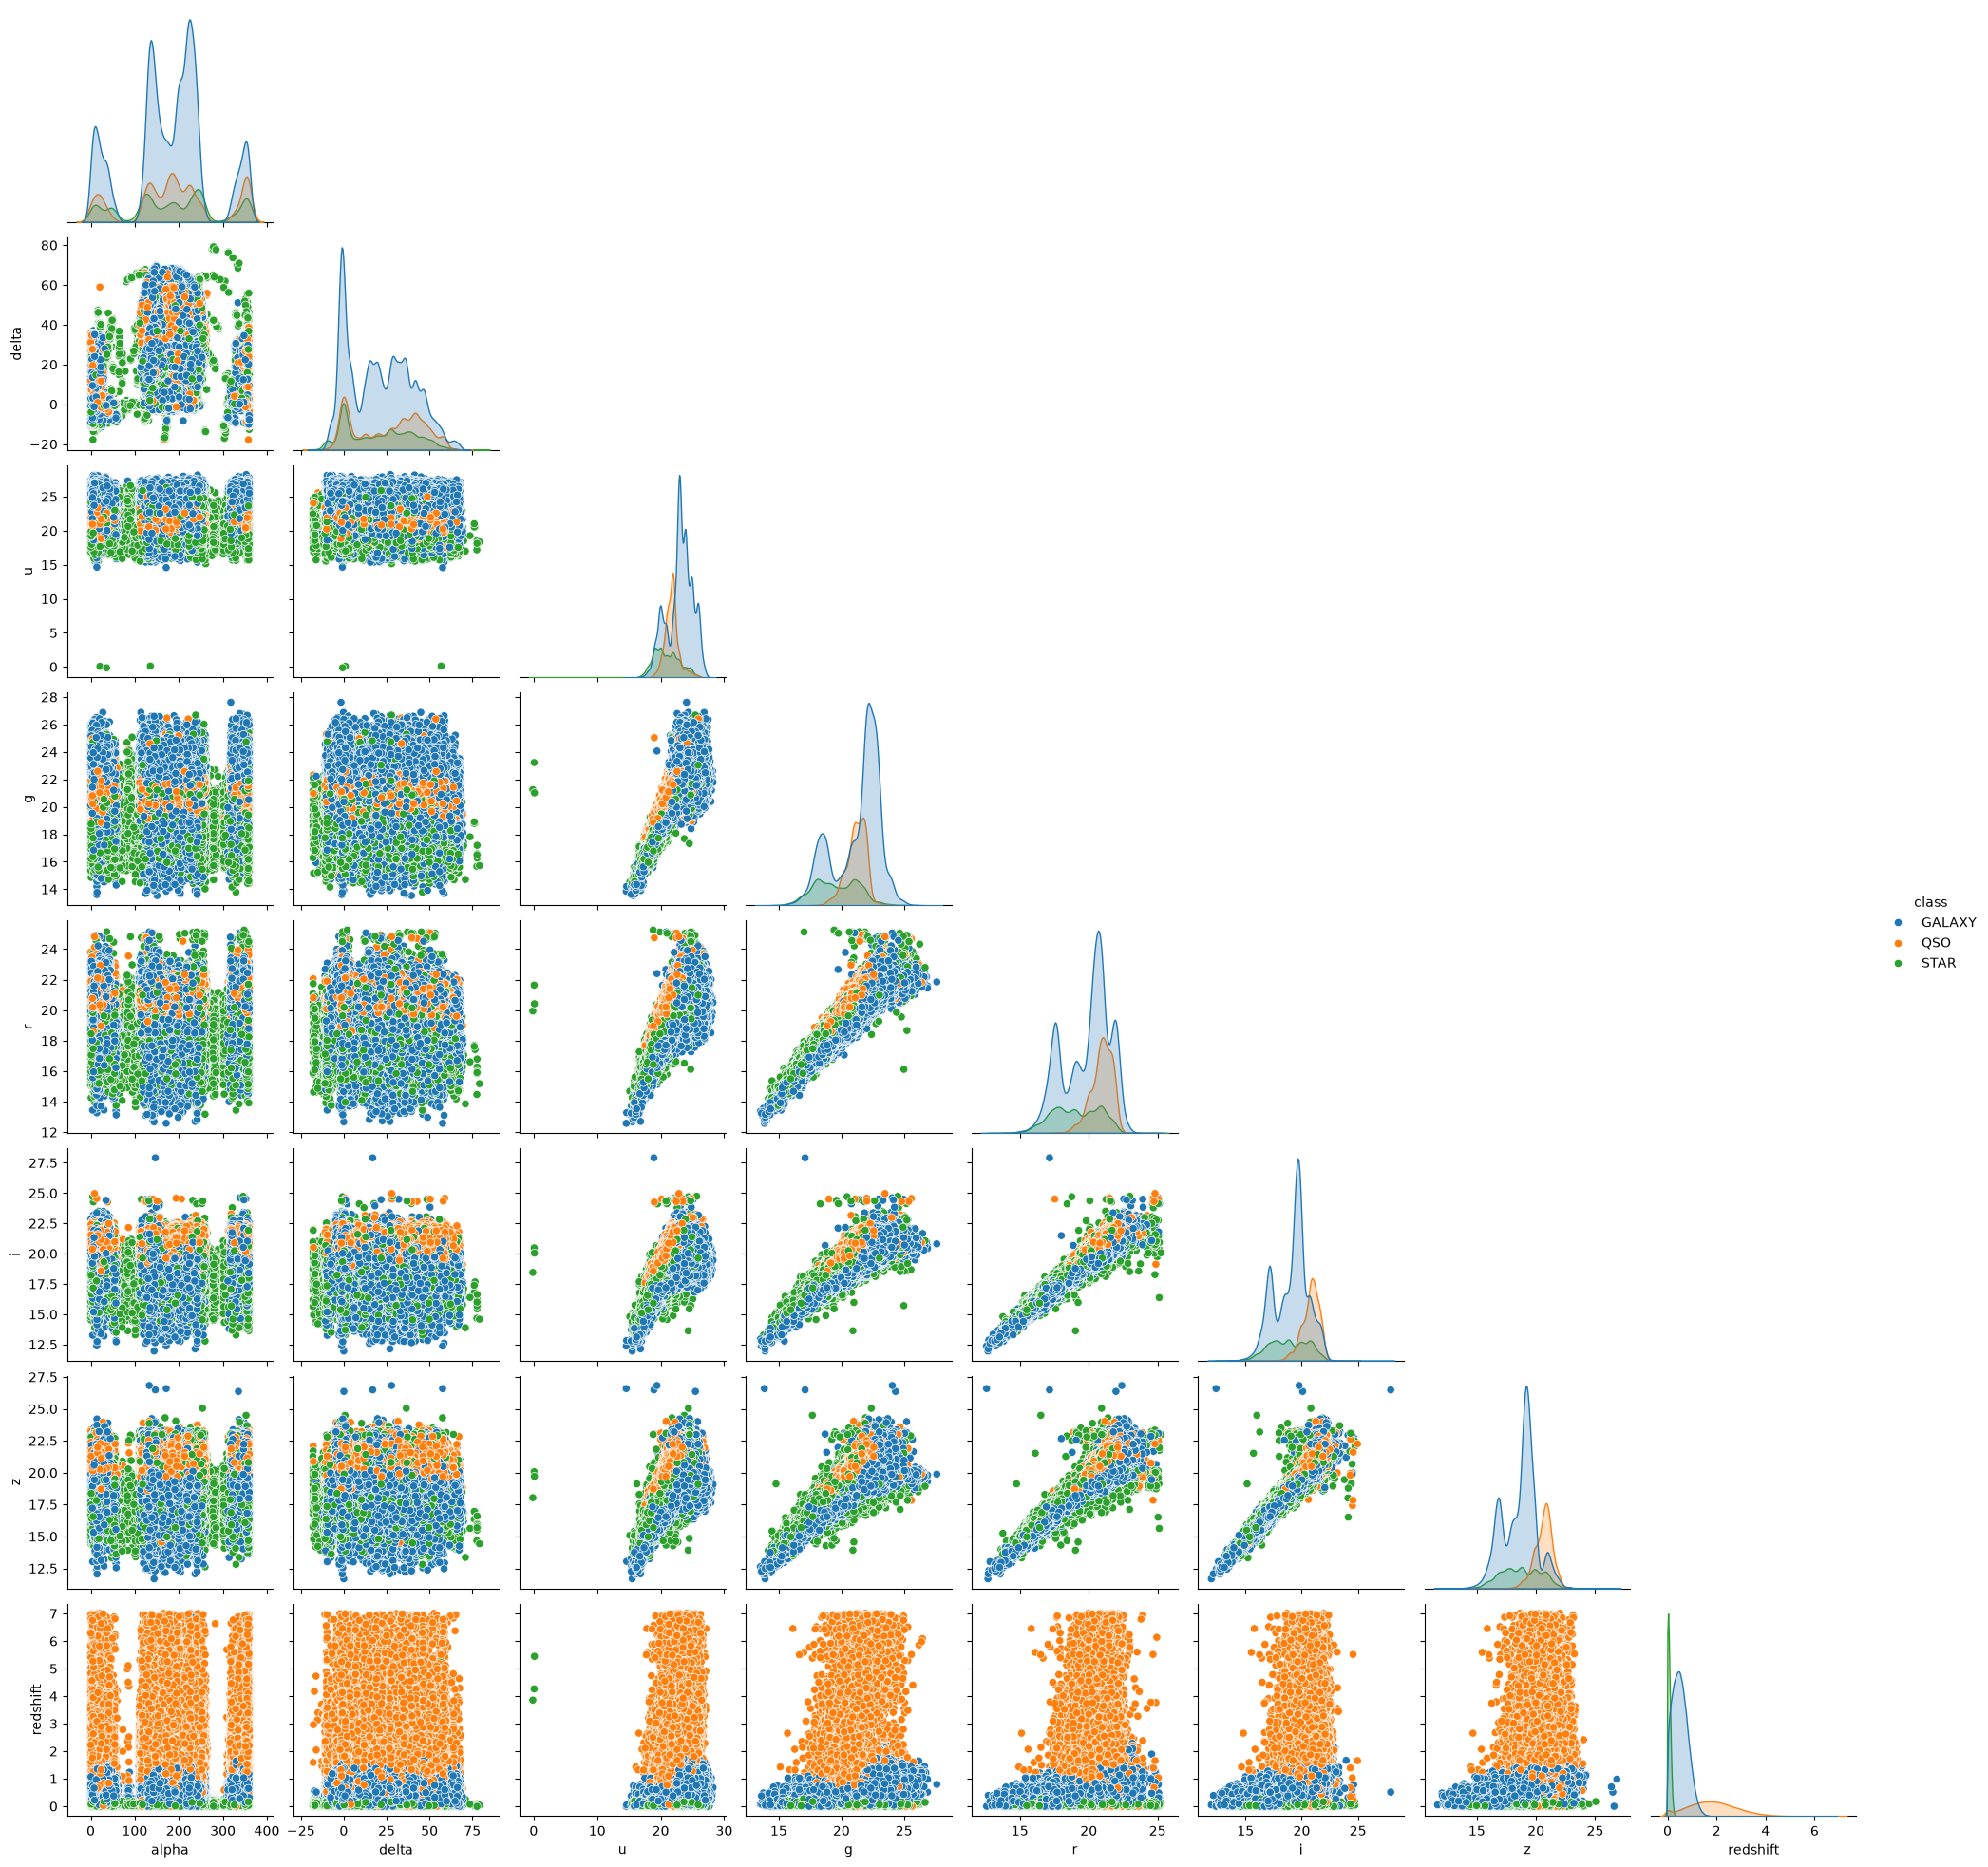

In [15]:
# Visualize using pairplot and add hue on class
sns.pairplot(data = train, hue = 'class', corner = True)
plt.show()

`Redshift` is the strongest feature. The three classes separate well.

### 4.3 Categorical Features

In [16]:
# Crosstab of spectral type and class
round(pd.crosstab(train['spectral_type'], train['class'], normalize = 'index') * 100, 0)

class,GALAXY,QSO,STAR
spectral_type,,,
A/F,20.0,50.0,30.0
G/K,57.0,19.0,24.0
M,95.0,1.0,4.0
O/B,8.0,71.0,21.0


- `M` almost entirely `GALAXY`.
- `O/B` is largely `QSO`.
- `A/F` leans `QSO`.
- `G/K` leans `GALAXY`.

In [17]:
# Crosstab of galaxy population and class
round(pd.crosstab(train['galaxy_population'], train['class'], normalize = 'index') * 100, 0)

class,GALAXY,QSO,STAR
galaxy_population,,,
Blue_Cloud,35.0,42.0,23.0
Red_Sequence,90.0,3.0,7.0


- `Red_Sequence` is largely `GALAXY`.
- `Blue_Cloud` leans `QSO`.

### 4.4 Missing Values

In [18]:
missing = train.isnull().mean().sort_values(ascending=False)
missing[missing > 0]

Series([], dtype: float64)

### 4.5 EDA Summary

- `u`, `g`, `r`, `i`, `z` appear to be tightly correlated with each other. But also seeing outliers.
- `redshift` is the strongest feature. The three classes separate well.
- `spectral_type`
    - `M` almost entirely `GALAXY`.
    - `O/B` is largely `QSO`.
    - `A/F` leans `QSO`.
    - `G/K` leans `GALAXY`.
- `galaxy_population`
    - `Red_Sequence` is largely `GALAXY`.
    - `Blue_Cloud` leans `QSO`.

## 5.0 Preprocessing

In [19]:
# Pipeline for scaler. This is will only be applied to Logistic Regression.
numerical_cols = X_train.select_dtypes(include = 'number').columns # Define numerical columns
pipeline_scaler = Pipeline([('scaler', RobustScaler())])
pipeline_scaler

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"with_centering with_centering: bool, default=TrueIf `True`, center the data before scaling.This will cause :meth:`transform` to raise an exception when attemptedon sparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_scaling with_scaling: bool, default=TrueIf `True`, scale the data to interquartile range.",True
,"quantile_range quantile_range: tuple (q_min, q_max), 0.0 < q_min < q_max < 100.0, default=(25.0, 75.0)Quantile range used to calculate `scale_`. By default this is equal tothe IQR, i.e., `q_min` is the first quantile and `q_max` is the thirdquantile... versionadded:: 0.18","(25.0, ...)"
,"copy copy: bool, default=TrueIf `False`, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"unit_variance unit_variance: bool, default=FalseIf `True`, scale data so that normally distributed features have avariance of 1. In general, if the difference between the x-values of`q_max` and `q_min` for a standard normal distribution is greaterthan 1, the dataset will be scaled down. If less than 1, the datasetwill be scaled up... versionadded:: 0.24",False


In [20]:
# Pipeline for one hot encoding
ohe_cols = ['spectral_type', 'galaxy_population'] # Define ohe columns
ohe = OneHotEncoder(sparse_output = False, handle_unknown = 'ignore', drop = 'first')
pipeline_ohe = Pipeline([('ohe', ohe)])
pipeline_ohe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('ohe', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",'first'
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a SciPy sparse matrix/arrayin ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",False
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category

In [21]:
# Logistic regression pipeline
preprocess_log = ColumnTransformer(transformers = [
    ('Scaler', pipeline_scaler, numerical_cols),
    ('OHE', pipeline_ohe, ohe_cols)], remainder='passthrough')

preprocess_log.set_output(transform="pandas") 

preprocess_log

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('Scaler', ...), ('OHE', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feat

In [22]:
# Pipeline for other models
preprocess = ColumnTransformer(transformers = [
    ('OHE', pipeline_ohe, ohe_cols)], remainder='passthrough')

preprocess.set_output(transform="pandas") 

preprocess

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('OHE', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. 

## 6.0 Modeling

### 6.1 Model Comparison

In [23]:
# Define Models
models = {
    'Dummy Classifier (Baseline)': Pipeline([("Preprocess", preprocess), ("Model", DummyClassifier(strategy='most_frequent'))]),
    'Logistic Regression': Pipeline([("Preprocess", preprocess_log), ("Model", LogisticRegression(random_state=RANDOM_STATE))]),
    'LightGBM': Pipeline([("Preprocess", preprocess), ("Model", LGBMClassifier(random_state=RANDOM_STATE, verbose=-1))])
    }

In [24]:
# Define cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Train all models and store results
results = []

for name, pipe in models.items():
    cv_out = cross_validate(
        pipe, X_train, y_train,
        cv=cv, scoring="balanced_accuracy", n_jobs=-1
    )
    results.append({
        "model": name,
        "balanced_accuracy": cv_out["test_score"].mean(),
        "std": cv_out["test_score"].std(),
        "fit_time_s": cv_out["fit_time"].mean(),
    })

results_df = (
    pd.DataFrame(results)
    .sort_values("balanced_accuracy", ascending=False)
    .reset_index(drop=True)
)

results_df.round(2)

,model,balanced_accuracy,std,fit_time_s
0,LightGBM,0.95,0.0,212.93
1,Logistic Regression,0.89,0.0,2.01
2,Dummy Classifier (Baseline),0.33,0.0,0.21


### 6.2 Hyperparameter Tuning

In [25]:
# 1. tune on a subsample, not all 460k rows
sample = X_train.sample(n=80_000, random_state=RANDOM_STATE)
X_s = preprocess.fit_transform(sample)          # transform ONCE, outside the search
y_s = y_train[sample.index]

param_dist = {
    "n_estimators":      randint(100, 400),
    "learning_rate":     uniform(0.05, 0.15),
    "num_leaves":        randint(20, 80),
    "min_child_samples": randint(20, 150),
    "colsample_bytree":  uniform(0.7, 0.3),
}

search = RandomizedSearchCV(
    LGBMClassifier(random_state=RANDOM_STATE, verbose=-1, n_jobs=-1),
    param_dist,
    n_iter=15,
    scoring="balanced_accuracy",
    cv=3,
    n_jobs=1,          # let LightGBM use the cores, not the search
    random_state=RANDOM_STATE,
)
search.fit(X_s, y_s)
print(search.best_score_, search.best_params_)

0.9496814669151323 {'colsample_bytree': np.float64(0.7446600666623686), 'learning_rate': np.float64(0.076649744184554), 'min_child_samples': 25, 'n_estimators': 222, 'num_leaves': 67}


## 7.0 Model Evaluation

### 7.1 Features of Importance

                                feature           gain  split
0                   remainder__redshift  403619.796225   5793
1                  OHE__spectral_type_M  144012.805680    287
2                          remainder__z   85977.862837   5456
3                          remainder__g   67651.268987   4930
4                          remainder__u   59311.926966   5094
5   OHE__galaxy_population_Red_Sequence   38132.180724    367
6                      remainder__alpha   33196.032097   6373
7                          remainder__i   32486.286388   4221
8                          remainder__r   28290.081019   4574
9                      remainder__delta   25918.475115   6347
10               OHE__spectral_type_G/K    2398.174622    354
11               OHE__spectral_type_O/B     738.059580    160


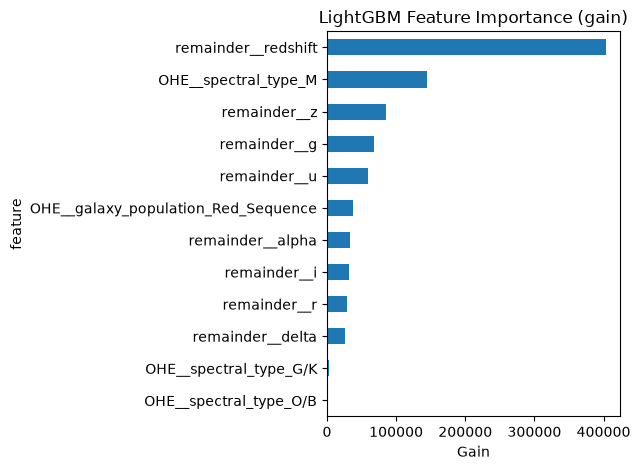

In [26]:
best = search.best_estimator_   # the bare LGBMClassifier from the search

# feature names came through because of set_output(transform="pandas")
feat_names = X_s.columns

imp = (
    pd.DataFrame({
        "feature": feat_names,
        "gain": best.booster_.feature_importance(importance_type="gain"),
        "split": best.booster_.feature_importance(importance_type="split"),
    })
    .sort_values("gain", ascending=False)
    .reset_index(drop=True)
)
print(imp)

imp.head(12).plot.barh(x="feature", y="gain", legend=False)
plt.gca().invert_yaxis()
plt.xlabel("Gain")
plt.title("LightGBM Feature Importance (gain)")
plt.tight_layout()
plt.show()

### 7.2 Model Predictions

In [27]:
# Make predictions on test set
y_pred = best.predict(preprocess.transform(X_test))

In [28]:
# Create submission csv
submission = pd.DataFrame({
    'id': test.index,
    'class': y_pred
})

submission.head()

,id,class
0,577347,GALAXY
1,577348,GALAXY
2,577349,GALAXY
3,577350,STAR
4,577351,GALAXY


In [29]:
# Save to csv
submission.to_csv('submission.csv', index=False)